In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/sales.csv')

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Set index
df.set_index('date', inplace=True)

print(df.head())

            sales
date             
2023-01-01    200
2023-01-02    210
2023-01-03    190
2023-01-04    220
2023-01-05    250


In [2]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10 entries, 2023-01-01 to 2023-01-10
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sales   10 non-null     int64
dtypes: int64(1)
memory usage: 160.0 bytes


In [4]:
df.head()

,sales
date,
2023-01-01,200
2023-01-02,210
2023-01-03,190
2023-01-04,220
2023-01-05,250


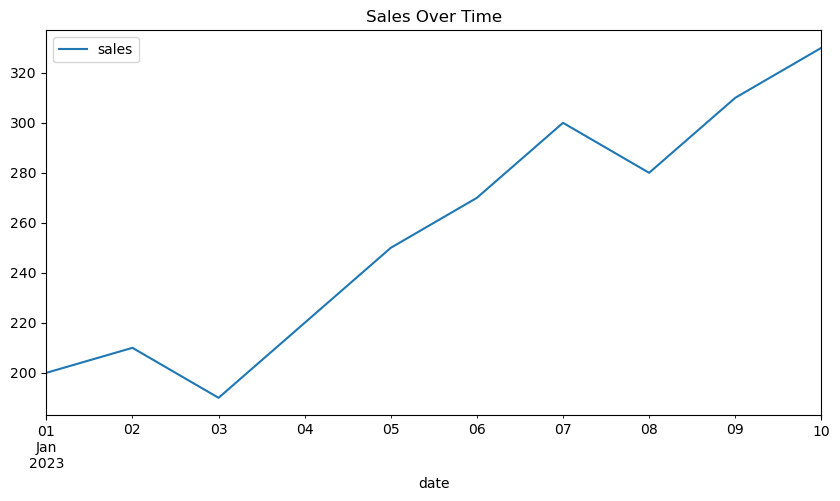

In [5]:
import matplotlib.pyplot as plt

df.plot(figsize=(10,5), title="Sales Over Time")
plt.show()

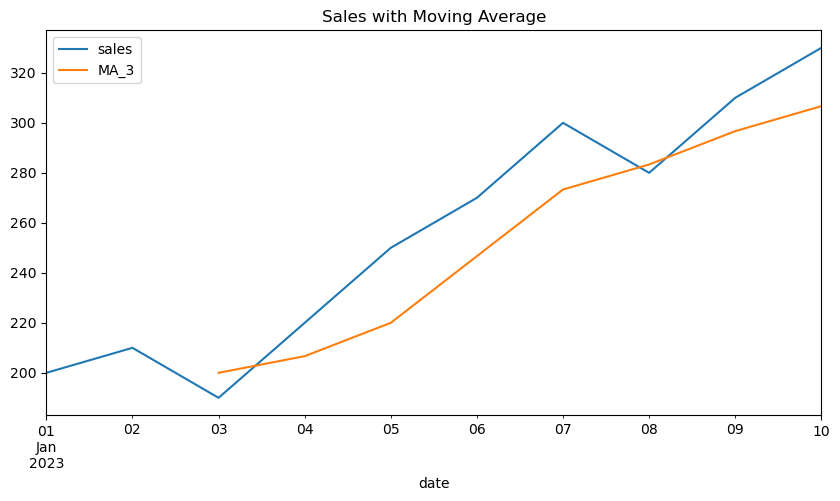

In [6]:
df['MA_3'] = df['sales'].rolling(window=3).mean()

df.plot(figsize=(10,5), title="Sales with Moving Average")
plt.show()

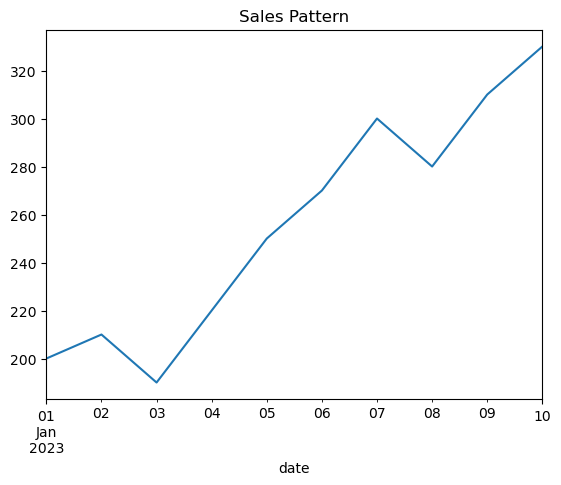

In [7]:
df['sales'].plot(title="Sales Pattern")
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.14742506814319384
p-value: 0.9445051103139898


In [9]:
df_diff = df.diff().dropna()

df_diff.head()

,sales,MA_3
date,,
2023-01-04,30.0,6.666667
2023-01-05,30.0,13.333333
2023-01-06,20.0,26.666667
2023-01-07,30.0,26.666667
2023-01-08,-20.0,10.000000


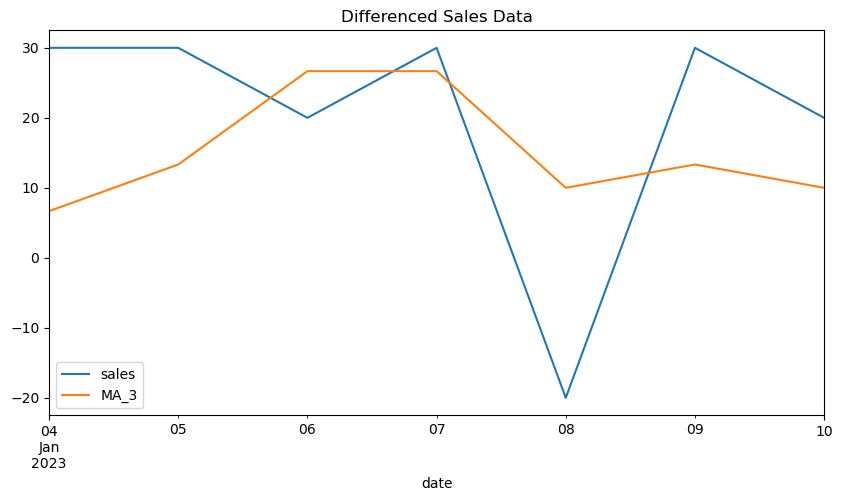

In [10]:
df_diff.plot(figsize=(10,5), title="Differenced Sales Data")
plt.show()

In [11]:
result_diff = adfuller(df_diff['sales'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -2.9831674264448225
p-value: 0.03649653305753666


In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['sales'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   10
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -40.772
Date:                Mon, 23 Mar 2026   AIC                             87.543
Time:                        13:34:33   BIC                             88.135
Sample:                    01-01-2023   HQIC                            86.266
                         - 01-10-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.012     86.422      0.000       0.977       1.023
ma.L1         -0.9959      1.046     -0.952      0.341      -3.046       1.054
sigma2       429.4641      0.002   1.75e+05      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization fai

In [18]:
forecast = model_fit.forecast(steps=5)
print(forecast)

2023-01-11    341.163038
2023-01-12    352.325823
2023-01-13    363.488352
2023-01-14    374.650627
2023-01-15    385.812648
Freq: D, Name: predicted_mean, dtype: float64


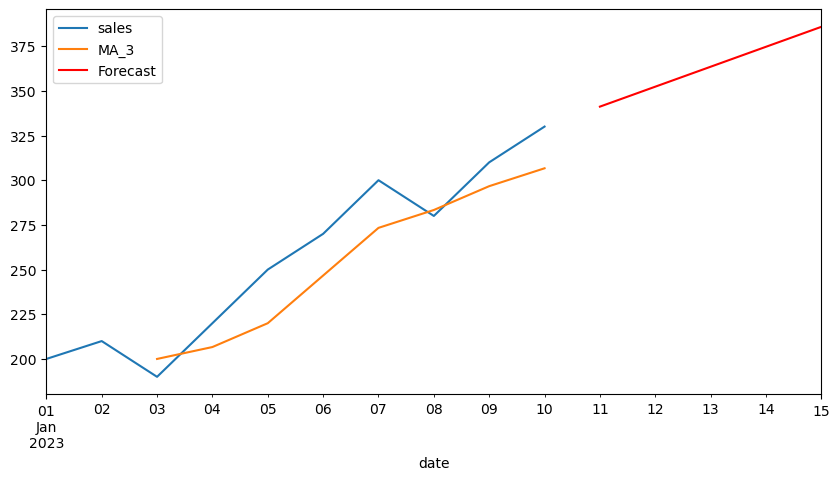

In [24]:
df.plot(figsize=(10,5), label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()





# ## 📊 Forecast Result

The ARIMA model was used to forecast future sales for the next 5 days.

### 📈 Observations:
- Sales show an increasing trend over time
- The forecast also predicts a continued upward trend
- This indicates consistent growth in sales

### ⚠️ Limitations:
- The dataset is very small
- Model performance may not be highly accurate
- In real-world scenarios, more data is required